# Importing required libraries

In [1]:
# pip install -r requirements.txt
!pip install yfinance


In [2]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

# Fetching Data from yahoo finance

In [3]:
START = "2012-01-01"
TODAY = date.today().strftime("%Y-%m-%d")
def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

In [4]:
data = load_data('TCS.NS')
df=data
df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2012-01-02,466.460938,469.369877,456.329096,459.495299,2248542
1,2012-01-03,473.980652,478.848709,467.015014,468.301284,2708884
2,2012-01-04,464.244690,476.909507,462.780340,476.869939,2386770
3,2012-01-05,463.848999,468.994082,462.008633,464.165639,2547312
4,2012-01-06,462.819885,470.319812,457.833124,461.474239,2119728


In [5]:
df = df.drop(['Date','Open','High','Low', 'Volume'], axis = 1)

<ipython-input-5-b762d74b983a>:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date','Open','High','Low', 'Volume'], axis = 1)


In [6]:
df.head()

Price,Close
Ticker,TCS.NS
0,466.460938
1,473.980652
2,464.244690
3,463.848999
4,462.819885


# Plotting Closing Price

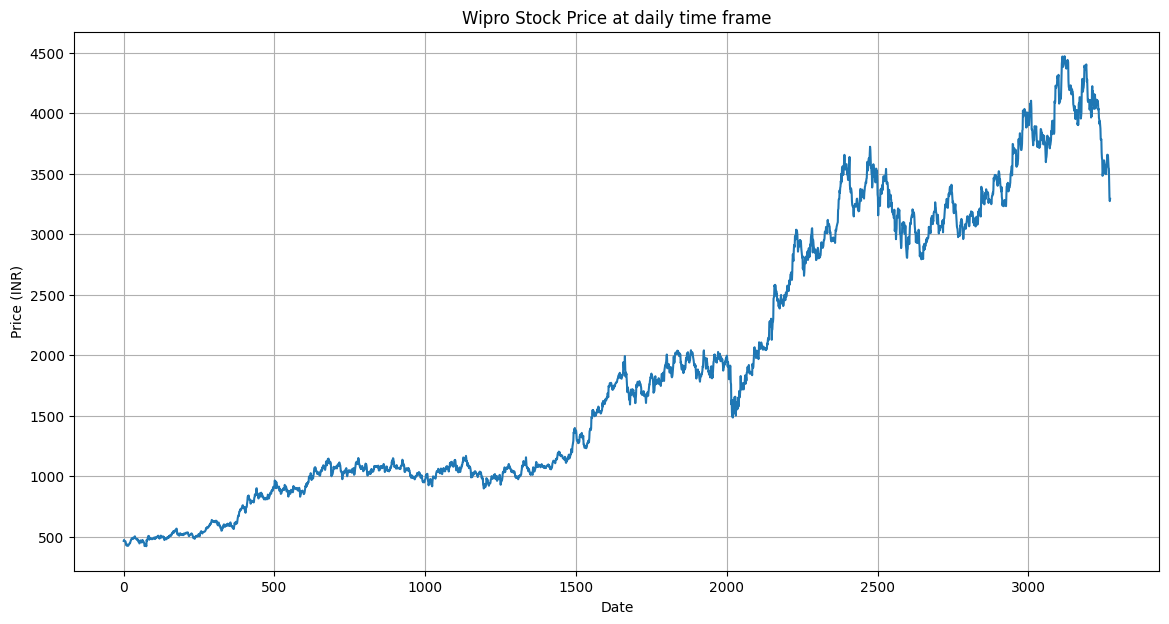

In [7]:
plt.figure(figsize=(14, 7))
plt.plot(df['Close'])
plt.title("Wipro Stock Price at daily time frame")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

In [8]:
df

Price,Close
Ticker,TCS.NS
0,466.460938
1,473.980652
2,464.244690
3,463.848999
4,462.819885
...,...
3267,3543.949951
3268,3403.149902
3269,3299.399902


In [9]:
df.shape

(3272, 1)

# Dataset Spliting for training (70%) and testing (30%)

In [10]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2012-01-02,466.460938,469.369877,456.329096,459.495299,2248542
1,2012-01-03,473.980652,478.848709,467.015014,468.301284,2708884
2,2012-01-04,464.244690,476.909507,462.780340,476.869939,2386770
3,2012-01-05,463.848999,468.994082,462.008633,464.165639,2547312
4,2012-01-06,462.819885,470.319812,457.833124,461.474239,2119728
...,...,...,...,...,...,...
3267,2025-04-02,3543.949951,3564.100098,3530.050049,3544.000000,1764313
3268,2025-04-03,3403.149902,3502.000000,3396.149902,3491.000000,4537821
3269,2025-04-04,3299.399902,3399.649902,3295.500000,3362.600098,5317367


In [11]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])
print(data.shape)
print(train.shape)
print(test.shape)

(3272, 6)
(2290, 6)
(982, 6)


In [12]:
train.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2012-01-02,466.460938,469.369877,456.329096,459.495299,2248542
1,2012-01-03,473.980652,478.848709,467.015014,468.301284,2708884
2,2012-01-04,464.244690,476.909507,462.780340,476.869939,2386770
3,2012-01-05,463.848999,468.994082,462.008633,464.165639,2547312
4,2012-01-06,462.819885,470.319812,457.833124,461.474239,2119728


In [13]:
test.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
2290,2021-04-22,2863.413574,2890.222454,2850.973086,2890.222454,1988980
2291,2021-04-23,2854.875488,2863.597571,2837.936330,2850.743975,1615309
2292,2021-04-26,2846.887207,2894.812701,2835.181257,2848.034849,2490260
2293,2021-04-27,2875.532471,2879.296827,2848.907170,2851.661511,1471417
2294,2021-04-28,2868.280029,2892.977206,2857.170760,2892.013142,1639037


# Dataset normalization by using MinMax scaler
---



In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [15]:
test

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
2290,2021-04-22,2863.413574,2890.222454,2850.973086,2890.222454,1988980
2291,2021-04-23,2854.875488,2863.597571,2837.936330,2850.743975,1615309
2292,2021-04-26,2846.887207,2894.812701,2835.181257,2848.034849,2490260
2293,2021-04-27,2875.532471,2879.296827,2848.907170,2851.661511,1471417
2294,2021-04-28,2868.280029,2892.977206,2857.170760,2892.013142,1639037
...,...,...,...,...,...,...
3267,2025-04-02,3543.949951,3564.100098,3530.050049,3544.000000,1764313
3268,2025-04-03,3403.149902,3502.000000,3396.149902,3491.000000,4537821
3269,2025-04-04,3299.399902,3399.649902,3295.500000,3362.600098,5317367


In [16]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [17]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.0138262 ],
       [0.01714097],
       [0.0203664 ],
       ...,
       [0.95680033],
       [0.93606443],
       [0.95541789]])

In [18]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [19]:
x_train.shape

(2190, 100, 1)

#  LSTM Model

---



In [20]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [21]:
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense

model = Sequential()

# First LSTM layer with more units and higher dropout rate
model.add(LSTM(units=100, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.3))  # Higher dropout for better regularization

# Second LSTM layer with more units and higher dropout rate
model.add(LSTM(units=150, activation='relu', return_sequences=True))
model.add(Dropout(0.4))  # Slightly higher dropout rate

# Third LSTM layer with more units and dropout
model.add(LSTM(units=200, activation='relu', return_sequences=True))
model.add(Dropout(0.5))  # Dropout increased further to prevent overfitting

# Fourth LSTM layer with more units
model.add(LSTM(units=250, activation='relu'))
model.add(Dropout(0.5))  # Same dropout rate for the last layer

# Output layer
model.add(Dense(units=1))  # Prediction of stock price (regression problem)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 100)            │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 100)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 150)            │         150,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 150)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 200)            │         280,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 200)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 250)                 │         451,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             251 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 923,451 (3.52 MB)

 Trainable params: 923,451 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

#  Model Training

---



In [23]:
import tensorflow as tf
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model.fit(x_train, y_train,epochs =5)

Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - loss: 0.0364 - mean_absolute_error: 0.1262
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0048 - mean_absolute_error: 0.0494
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0043 - mean_absolute_error: 0.0459
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0045 - mean_absolute_error: 0.0466
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0031 - mean_absolute_error: 0.0393


In [24]:
model.save('keras_model.h5')

In [25]:
test_close.shape

(982, 1)

In [26]:
past_80_days = pd.DataFrame(train_close[-80:])

In [27]:
test_df = pd.DataFrame(test_close)

# Defining the final test dataset by including the last 100 rows of the training dataset to predict the first column of the testing dataset.

---


In [28]:
# final_df = past_80_days.append(test_df, ignore_index = True)
final_df = pd.concat([past_80_days, test_df], ignore_index=True)

In [29]:
final_df.head()

,0
0,2596.992462
1,2635.525957
2,2665.720197
3,2666.636575
4,2675.800965


In [30]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.        ],
       [0.02032095],
       [0.03624412],
       ...,
       [0.40374929],
       [0.26526504],
       [0.37181774]])

In [31]:
input_data.shape

(1062, 1)

# Testing the model

---



In [32]:
x_test = []
y_test = []
for i in range(80, input_data.shape[0]):
   x_test.append(input_data[i-80: i])
   y_test.append(input_data[i, 0])

In [33]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(982, 80, 1)
(982,)


# Prediction of Closing Price and plotting the Graph

---



In [34]:
# Making predictions

y_pred = model.predict(x_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step


In [35]:
y_pred.shape

(982, 1)

In [37]:
y_test

array([0.15463718, 0.13381788, 0.13238921, 0.13430175, 0.15558151,
       0.15347511, 0.13091248, 0.09503507, 0.11338568, 0.11687131,
       0.13405985, 0.14737471, 0.15364463, 0.14350149, 0.14108033,
       0.13067042, 0.10960885, 0.1313969 , 0.12365   , 0.11546764,
       0.11251423, 0.12243973, 0.13484658, 0.1484694 , 0.16887995,
       0.18228421, 0.16306608, 0.17211575, 0.16347953, 0.16527968,
       0.15236188, 0.16063325, 0.18641994, 0.18836595, 0.19225849,
       0.19301273, 0.2258297 , 0.2350741 , 0.2176073 , 0.21926178,
       0.26081227, 0.21901832, 0.23799349, 0.25015719, 0.22826271,
       0.27265943, 0.28056597, 0.25648219, 0.25842815, 0.26426688,
       0.25113035, 0.2564821 , 0.24237255, 0.2238838 , 0.23507432,
       0.21172045, 0.20442205, 0.19420459, 0.18106797, 0.20424858,
       0.19712971, 0.18103844, 0.18328157, 0.18591478, 0.20541901,
       0.1907906 , 0.19079073, 0.18493949, 0.19091271, 0.20005537,
       0.18103881, 0.20493158, 0.23955154, 0.22736136, 0.22616

In [38]:
y_pred

array([[0.16849431],
       [0.1719723 ],
       [0.17489776],
       [0.17716813],
       [0.17873451],
       [0.17963263],
       [0.17994079],
       [0.17972112],
       [0.17898384],
       [0.17776093],
       [0.17611036],
       [0.17413124],
       [0.17195398],
       [0.1697169 ],
       [0.16752613],
       [0.16545361],
       [0.16352773],
       [0.16172343],
       [0.16003126],
       [0.15843803],
       [0.15692064],
       [0.15545478],
       [0.15403476],
       [0.15268108],
       [0.15144259],
       [0.15040252],
       [0.14966214],
       [0.14927062],
       [0.14925313],
       [0.14959331],
       [0.15025246],
       [0.15115628],
       [0.15223521],
       [0.15347221],
       [0.15487114],
       [0.15644258],
       [0.1581907 ],
       [0.16016841],
       [0.16244721],
       [0.16504484],
       [0.16794172],
       [0.17117399],
       [0.17469323],
       [0.17844692],
       [0.18239933],
       [0.18646923],
       [0.19064999],
       [0.194

In [39]:
scaler.scale_

array([0.00052736])

In [40]:
scale_factor = 1/0.00041967
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor
y_pred

array([[ 401.4924 ],
       [ 409.77985],
       [ 416.7507 ],
       [ 422.1606 ],
       [ 425.893  ],
       [ 428.03308],
       [ 428.76736],
       [ 428.24393],
       [ 426.48712],
       [ 423.57312],
       [ 419.6401 ],
       [ 414.92422],
       [ 409.73618],
       [ 404.4056 ],
       [ 399.1854 ],
       [ 394.24695],
       [ 389.6579 ],
       [ 385.35858],
       [ 381.32645],
       [ 377.53006],
       [ 373.91437],
       [ 370.4215 ],
       [ 367.03784],
       [ 363.81226],
       [ 360.86115],
       [ 358.38284],
       [ 356.61865],
       [ 355.68573],
       [ 355.64404],
       [ 356.45462],
       [ 358.02527],
       [ 360.17892],
       [ 362.74982],
       [ 365.6974 ],
       [ 369.03076],
       [ 372.77524],
       [ 376.9407 ],
       [ 381.65323],
       [ 387.08322],
       [ 393.27292],
       [ 400.1757 ],
       [ 407.87762],
       [ 416.26334],
       [ 425.20773],
       [ 434.62564],
       [ 444.3235 ],
       [ 454.2855 ],
       [ 464.

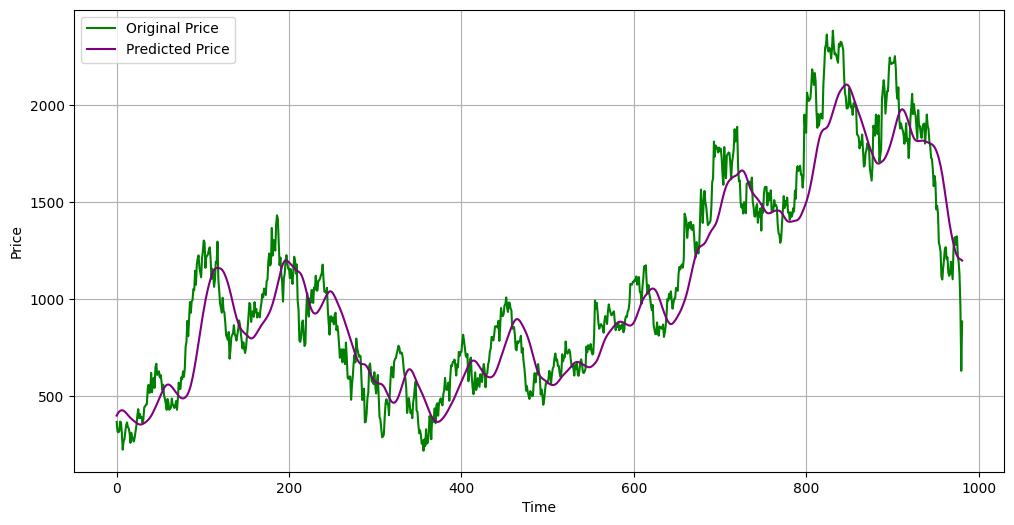

In [41]:
import matplotlib.pyplot as plt

#  y_test and y_pred are  data arrays
plt.figure(figsize=(12, 6))

# Custom colors: Green for Original Price and Purple for Predicted Price
plt.plot(y_test, 'g', label="Original Price")  # Green
plt.plot(y_pred, '#800080', label="Predicted Price")  # Purple using hex code

plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Model Evaluation

Calculation of mean absolute error and R2 Score

In [42]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae_percentage = (mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))


Mean absolute error on test set: 13.53%


In [43]:
from sklearn.metrics import r2_score
actual = y_test
predicted = y_pred
r2 = r2_score(actual, predicted)
print("R2 score:", r2)

R2 score: 0.8799002067592278


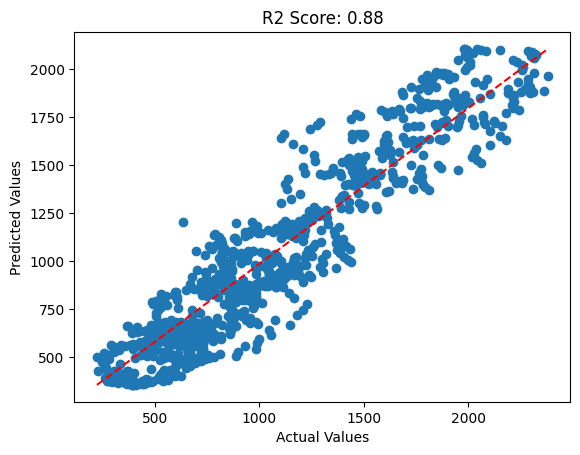

In [44]:
plt.scatter(actual, predicted)
plt.plot([min(actual), max(actual)], [min(predicted), max(predicted)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'R2 Score: {r2:.2f}')
plt.show()